# AI Agent Bug-Fixing: Novel Findings (Dec 2024 – Feb 2026)

A 15-month study of how AI agents (Copilot, Cursor, Claude Code, Devin) fix bugs, vs. human authors.
Each section = a **question**, a **chart**, a **plain answer**, and an **honest caveat**.

**Part A — the three over-time questions:**
1. How does each quality metric change over time?
2. Do repositories change which agent they use over time?
3. Do developers change their instructions to agents over time?

**Part B — the bug-fix domain contributions:**
4. Do agents fix different *kinds* of bugs?
5. Do agents really merge bug-fixes better than humans? (repo-matched)
6. Do agent fixes *hold up*? (reverts)
7. *How* do agents fix — patch size by file role?

In [1]:
import sys; sys.path.insert(0,'.')
from pathlib import Path
from analysis_utils import (
    load_fix_prs, load_commits, load_commit_details, build_revision_stats,
    build_matched_human_baseline, merge_rate, chi_square, odds_ratio_ci, sig_label,
    classify_file_role, classify_bug_type, BUG_CATEGORIES,
    set_plot_style, save_fig, AGENTS, AGENT_COLORS, MIN_N_PROP, MIN_N_MEDIAN,
)
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
set_plot_style()
FIG = Path('results/paper_findings_figures')
CATS = list(BUG_CATEGORIES) + ['other']

# ---- load everything once ----
df = load_fix_prs()
df['bug_type'] = df['title'].map(classify_bug_type)
agents_df = df[df.is_agent & df.agent.isin(AGENTS)].copy()
human_df  = df[~df.is_agent].copy()
commits = load_commits()
details = load_commit_details()
rev_stats = build_revision_stats(df, commits, details)
agent_rev = rev_stats[rev_stats.agent.isin(AGENTS)].copy()
matched   = build_matched_human_baseline(df)
m_human_df = matched[~matched.is_agent].copy()

# lines added per PR, split by file role
details['role'] = details['filename'].map(classify_file_role)
role_add = details.groupby(['pr_id','role'])['additions'].sum().unstack(fill_value=0)
role_add.columns = [f'{c}_added' for c in role_add.columns]
for c in ['prod_added','test_added','generated_added']:
    if c not in role_add: role_add[c] = 0.0
df_size = df.merge(role_add, left_on='id', right_index=True, how='left')
agents_size = df_size[df_size.is_agent & df_size.agent.isin(AGENTS)]
human_size  = df_size[~df_size.is_agent]

months = sorted(df['month'].unique()); idx = [str(m) for m in months]
print('Ready:', f'{len(df):,} fix PRs |', len(months), 'months |',
      f'{len(agents_df):,} agent, {len(human_df):,} human')

Loading fix PRs from HuggingFace ...


  AIDev repo coverage: 8,959 distinct repos
  Survivorship cutoff at 2026-01-29: dropped 33,123 recent PRs
  Fix PRs loaded: 371,577  |  Agent: 108,080  |  Human: 263,497


Loading commits from HuggingFace ...


  Commits loaded: 1,156,238
Loading commit details from HuggingFace ...


  Commit details loaded: 7,451,150


  Matched baseline: 108,080 agent PRs + 52,418 matched human PRs (from 263,497 human PRs)


Ready: 371,577 fix PRs | 14 months | 108,080 agent, 263,497 human


## 1. How does each quality metric change over time?

  -> Saved: results\paper_findings_figures\q1_metrics_over_time.png


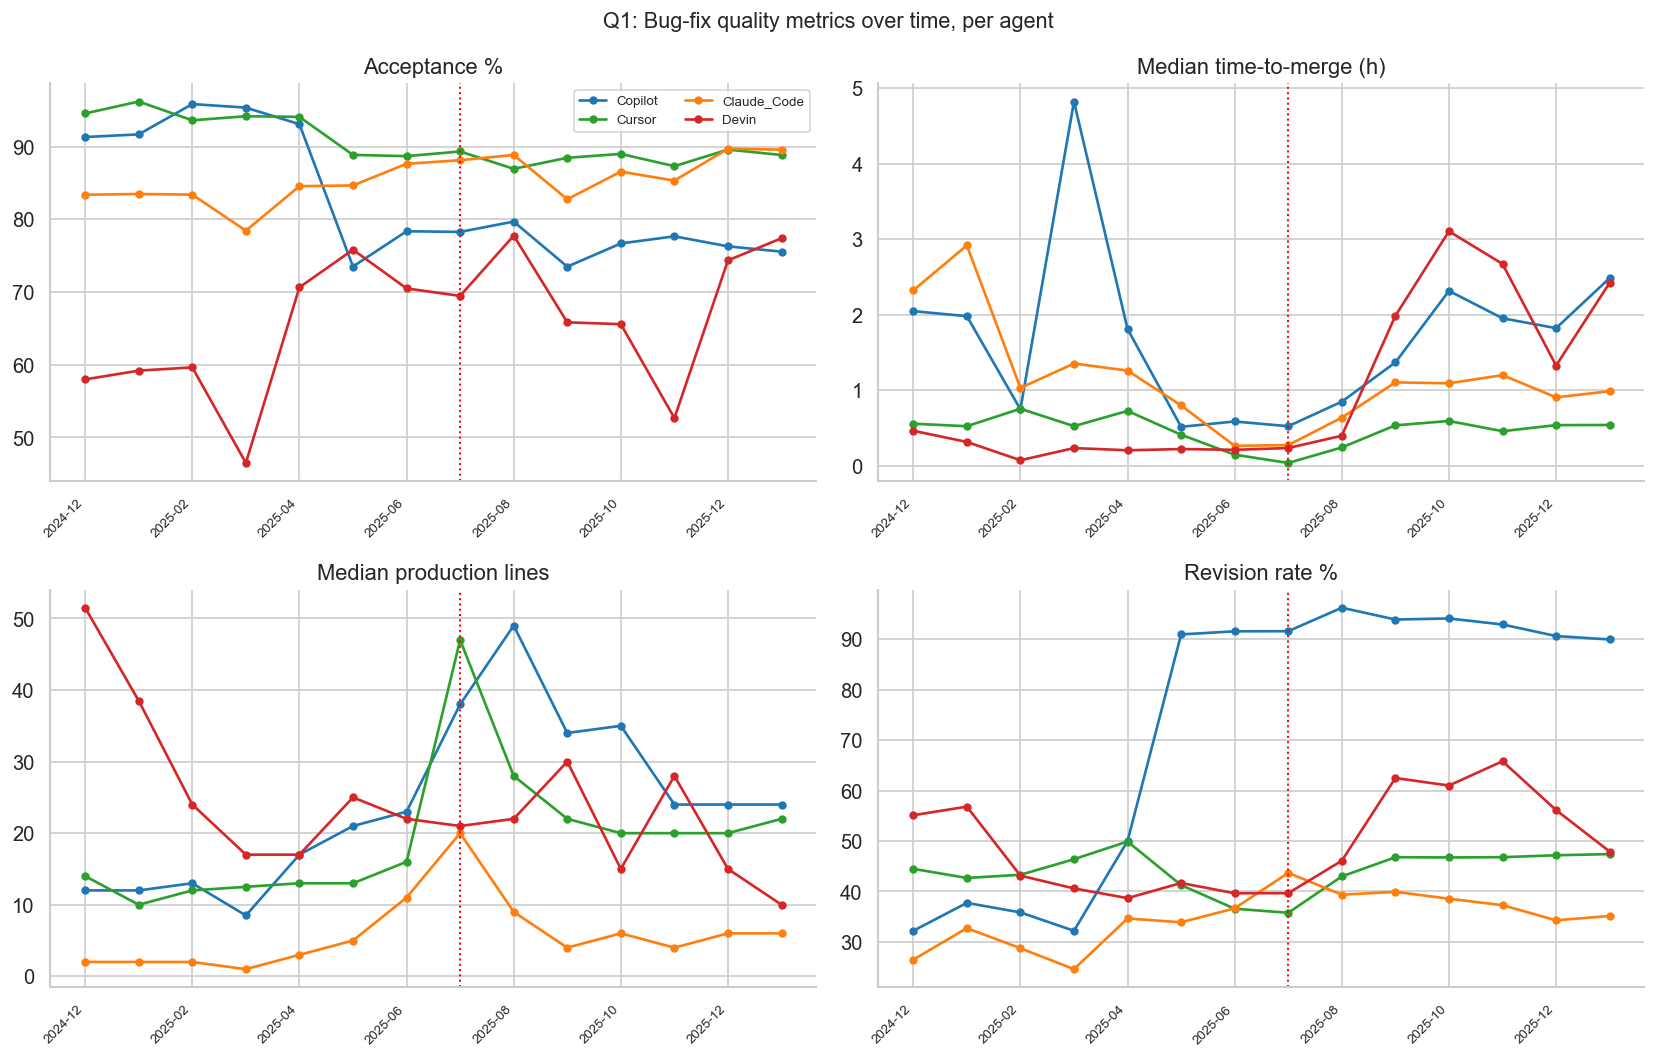

  Copilot      acceptance 91% -> 76%
  Cursor       acceptance 95% -> 89%
  Claude_Code  acceptance 83% -> 90%
  Devin        acceptance 58% -> 77%


In [2]:
def monthly(agent, metric):
    out=[]
    for m in months:
        if metric=='acceptance':
            s=agents_df[(agents_df.month==m)&(agents_df.agent==agent)]
            out.append(s.is_merged.mean()*100 if len(s)>=MIN_N_PROP else np.nan)
        elif metric=='ttm':
            s=agents_df[(agents_df.month==m)&(agents_df.agent==agent)&agents_df.is_merged]
            out.append(s.hours_to_merge.median() if len(s)>=MIN_N_MEDIAN else np.nan)
        elif metric=='prodsize':
            s=agents_size[(agents_size.month==m)&(agents_size.agent==agent)]
            out.append(s.prod_added.median() if len(s)>=MIN_N_MEDIAN else np.nan)
        elif metric=='revision':
            s=agent_rev[(agent_rev.month==m)&(agent_rev.agent==agent)]
            out.append((s.num_commits>1).mean()*100 if len(s)>=MIN_N_PROP else np.nan)
    return out

PANELS=[('acceptance','Acceptance %'),('ttm','Median time-to-merge (h)'),
        ('prodsize','Median production lines'),('revision','Revision rate %')]
fig,axes=plt.subplots(2,2,figsize=(14,9)); x=list(range(len(idx)))
for ax,(mk,lbl) in zip(axes.ravel(),PANELS):
    for a in AGENTS: ax.plot(idx,monthly(a,mk),'o-',color=AGENT_COLORS[a],label=a,lw=1.6,ms=4)
    ax.axvline('2025-07',color='red',ls=':',lw=1.2)
    ax.set_title(lbl); ax.set_xticks(x[::2]); ax.set_xticklabels(idx[::2],rotation=45,ha='right',fontsize=8)
axes.ravel()[0].legend(fontsize=8,ncol=2)
fig.suptitle('Q1: Bug-fix quality metrics over time, per agent',fontsize=13); fig.tight_layout()
save_fig(fig,'q1_metrics_over_time',FIG,show=True)
for a in AGENTS:
    v=[x for x in monthly(a,'acceptance') if not np.isnan(x)]
    print(f'  {a:<12} acceptance {v[0]:.0f}% -> {v[-1]:.0f}%')

**Answer:** the agents move in **opposite directions** — Claude Code & Devin improve, Copilot & Cursor decline; patch sizes drift up; Copilot's revision rate jumps to ~91% around May 2025.

**How:** for each agent and month — % merged (acceptance), median open→merge hours (TTM), median production lines, and % of merged PRs with >1 commit (revision); months with <30 PRs (rates) or <20 (medians) are dropped.

**Caveat:** the Copilot revision jump is likely a commit-counting/product quirk, not real rework; read the last 1–2 months gently (slow merges may be unfinished).

## 2. Do repositories change which agent they use over time?

Repos active >=2 months: 3,222 | kept same agent: 85% | switched: 15%
  -> Saved: results\paper_findings_figures\q2_agent_share.png


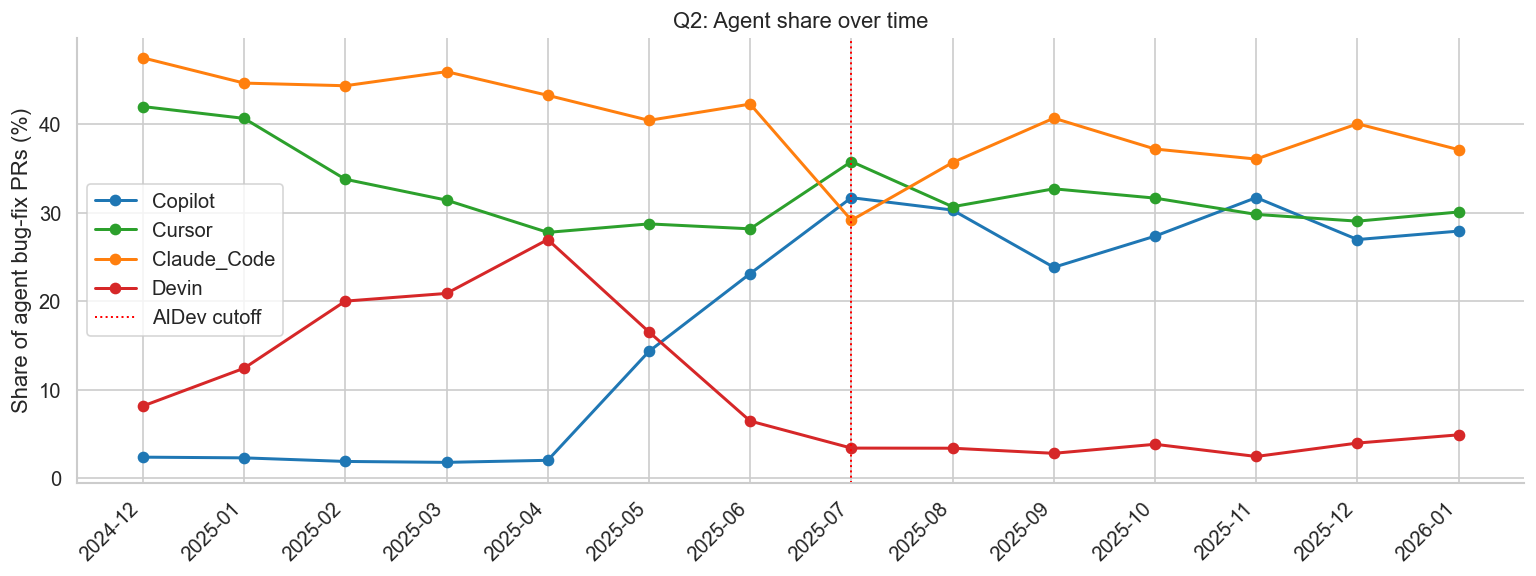

WindowsPath('results/paper_findings_figures/q2_agent_share.png')

In [3]:
per_agent=(agents_df.groupby(['month','agent']).size().unstack(fill_value=0).reindex(columns=AGENTS,fill_value=0))
share=per_agent.div(per_agent.sum(axis=1),axis=0)*100
g=agents_df.groupby(['repo','month','agent']).size().reset_index(name='n').sort_values(['repo','month','n'])
dom=g.drop_duplicates(['repo','month'],keep='last')[['repo','month','agent']]
multi=dom.groupby('repo').filter(lambda x:x['month'].nunique()>=2)
switched=multi.groupby('repo')['agent'].nunique().gt(1).sum(); n=multi['repo'].nunique()
print(f'Repos active >=2 months: {n:,} | kept same agent: {100*(n-switched)/n:.0f}% | switched: {100*switched/n:.0f}%')
fig,ax=plt.subplots(figsize=(13,5))
for a in AGENTS: ax.plot(idx,share[a].values,'o-',color=AGENT_COLORS[a],label=a,lw=1.8)
ax.axvline('2025-07',color='red',ls=':',lw=1.2,label='AIDev cutoff')
ax.set_ylabel('Share of agent bug-fix PRs (%)'); ax.set_title('Q2: Agent share over time')
plt.xticks(rotation=45,ha='right'); ax.legend(); fig.tight_layout()
save_fig(fig,'q2_agent_share',FIG,show=True)

**Answer:** mostly **no** — ~85% of repos keep the same main agent. The market shifts (Devin spikes then collapses, Copilot surges) because **new repos arrive**, not because existing repos switch.

**How:** for each repo, take its most-used agent each month; a repo "switched" if that top agent changed across its active months (repos active in ≥2 months).

**Caveat:** "who switches" is per **repository** (agent PRs come from bot accounts, so we can't track individual developers).

## 3. Do developers change their instructions to agents over time?

Fix PRs touching instr files: 2,222 (0.60%), 837 repos
Agent acceptance: WITH instr 85.7% vs WITHOUT 82.9%
  -> Saved: results\paper_findings_figures\q3_instruction_files.png


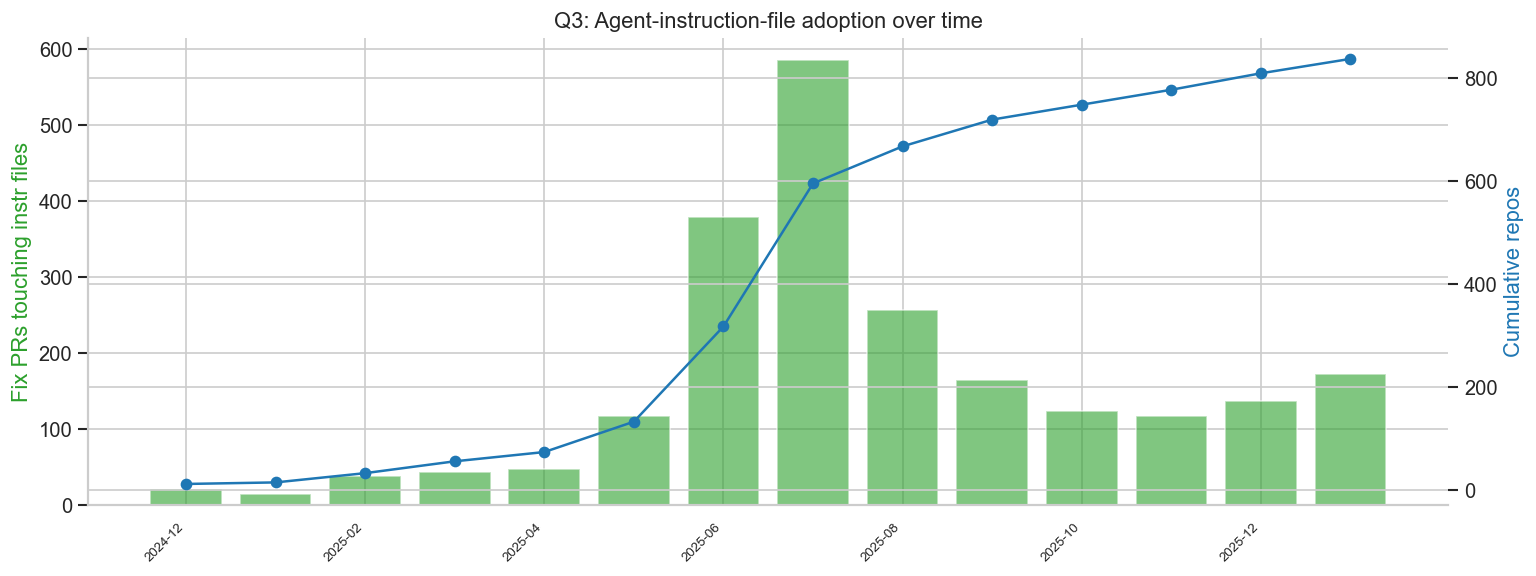

WindowsPath('results/paper_findings_figures/q3_instruction_files.png')

In [4]:
ipat=r'CLAUDE\.md|AGENTS?\.md|GEMINI\.md|\.cursorrules|\.cursor/rules/|copilot-instructions|\.windsurfrules|\.clinerules'
details['is_instr']=details['filename'].str.contains(ipat,case=False,regex=True,na=False)
df['touches_instr']=df['id'].isin(set(details.loc[details.is_instr,'pr_id']))
m_instr=df[df.touches_instr].groupby('month').size().reindex(months,fill_value=0)
cum=(df[df.touches_instr].groupby('repo')['month'].min().value_counts().reindex(months,fill_value=0).cumsum())
irepos=set(df.loc[df.touches_instr,'repo'])
print(f'Fix PRs touching instr files: {df.touches_instr.sum():,} ({df.touches_instr.mean()*100:.2f}%), {len(irepos):,} repos')
print(f'Agent acceptance: WITH instr {agents_df[agents_df.repo.isin(irepos)].is_merged.mean()*100:.1f}% '
      f'vs WITHOUT {agents_df[~agents_df.repo.isin(irepos)].is_merged.mean()*100:.1f}%')
fig,ax=plt.subplots(figsize=(13,5)); x=list(range(len(idx)))
ax.bar(x,m_instr.values,color='#2ca02c',alpha=0.6); ax2=ax.twinx(); ax2.plot(x,cum.values,'o-',color='#1f77b4')
ax.set_xticks(x[::2]); ax.set_xticklabels(idx[::2],rotation=45,ha='right',fontsize=8)
ax.set_ylabel('Fix PRs touching instr files',color='#2ca02c'); ax2.set_ylabel('Cumulative repos',color='#1f77b4')
ax.set_title('Q3: Agent-instruction-file adoption over time'); fig.tight_layout()
save_fig(fig,'q3_instruction_files',FIG,show=True)

**Answer:** **yes** — edits to instruction files (CLAUDE.md, .cursorrules, copilot-instructions.md, ...) rise over time; repos that use them have slightly higher agent acceptance.

**How:** flag changed files named CLAUDE.md/.cursorrules/copilot-instructions.md/AGENTS.md…; count PRs and repos touching them per month; compare agent merge rate in repos that ever touched one vs. not.

**Caveat:** lower bound (only edits inside fix PRs are visible) and the acceptance link is associational.

## 4. Do agents fix different *kinds* of bugs than humans?

  -> Saved: results\paper_findings_figures\f4_bug_types.png


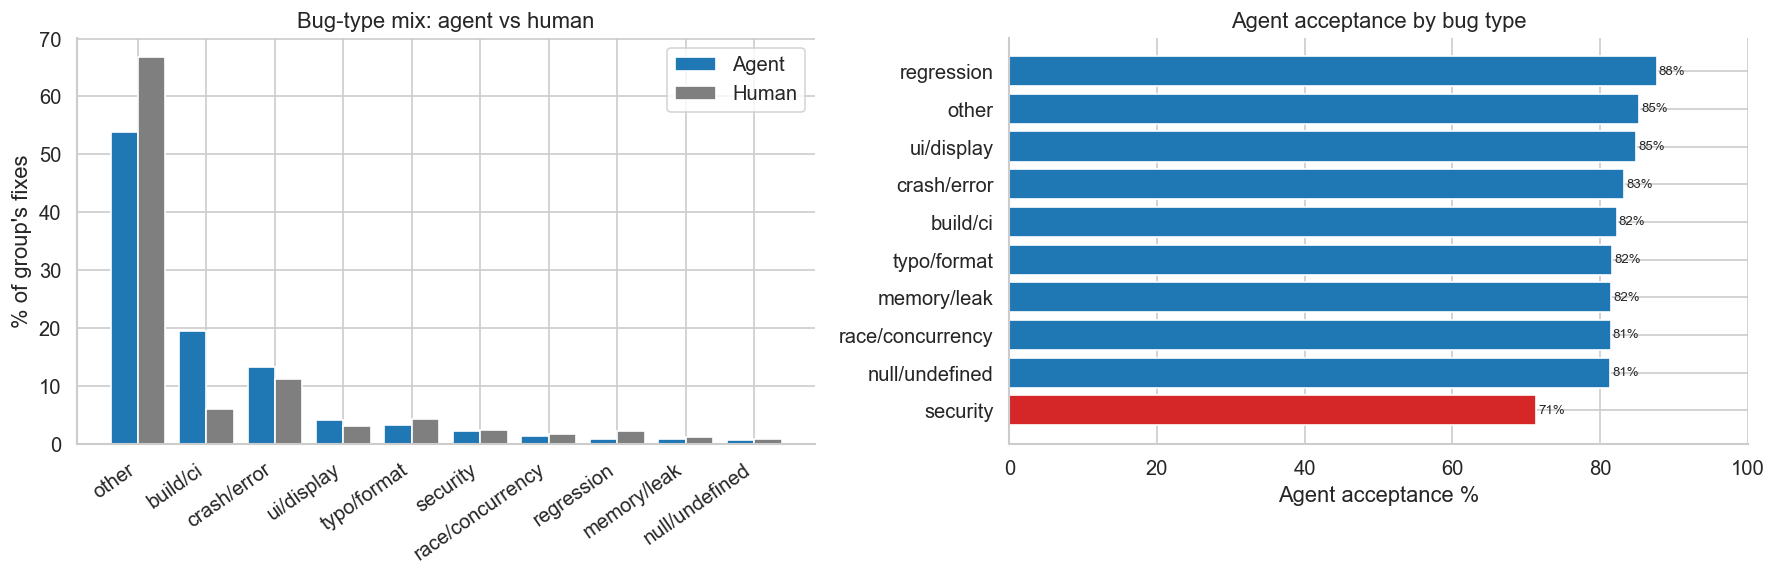

build/ci: agent 19.4% vs human 6.0% | security acceptance 71.3%


In [5]:
a_sh=agents_df.bug_type.value_counts(normalize=True).reindex(CATS).fillna(0)*100
h_sh=human_df.bug_type.value_counts(normalize=True).reindex(CATS).fillna(0)*100
order=a_sh.sort_values(ascending=False).index.tolist()
acc=sorted([(c,agents_df[agents_df.bug_type==c].is_merged.mean()*100) for c in CATS
            if (agents_df.bug_type==c).sum()>=200], key=lambda t:t[1])
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,5)); x=np.arange(len(order)); w=0.4
ax1.bar(x-w/2,a_sh[order].values,w,label='Agent',color='#1f77b4')
ax1.bar(x+w/2,h_sh[order].values,w,label='Human',color='#7f7f7f')
ax1.set_xticks(x); ax1.set_xticklabels(order,rotation=35,ha='right'); ax1.legend()
ax1.set_ylabel("% of group's fixes"); ax1.set_title('Bug-type mix: agent vs human')
cs=[c for c,_ in acc]; vs=[v for _,v in acc]
ax2.barh(cs,vs,color=['#d62728' if c=='security' else '#1f77b4' for c in cs])
for i,v in enumerate(vs): ax2.text(v+0.3,i,f'{v:.0f}%',va='center',fontsize=8)
ax2.set_xlim(0,100); ax2.set_xlabel('Agent acceptance %'); ax2.set_title('Agent acceptance by bug type')
fig.tight_layout(); save_fig(fig,'f4_bug_types',FIG,show=True)
print(f'build/ci: agent {a_sh["build/ci"]:.1f}% vs human {h_sh["build/ci"]:.1f}% | security acceptance {agents_df[agents_df.bug_type=="security"].is_merged.mean()*100:.1f}%')

**Answer:** **yes** — agents do **~3× more build/CI/dependency fixes** (19% vs 6%); their **security fixes are accepted least** (~71%).

**How:** label each PR by keywords in its title; compare the bug-type mix (% of each group) and the agent merge rate within each type.

**Caveat:** bug type is from title keywords (~half land in 'other') — trust the big build/CI gap, not small categories.

## 5. Do agents really merge bug-fixes better than humans? (repo-matched)

Human acceptance — all repos: 85.4%  |  repo-matched: 86.3%
Agent         Rate%             OR vs all         OR vs matched
Copilot       77.7%   OR=0.60[0.58,0.62] ***   OR=0.55[0.53,0.57] ***
Cursor        89.8%   OR=1.51[1.45,1.56] ***   OR=1.40[1.34,1.46] ***
Claude_Code   86.2%   OR=1.07[1.04,1.10] ***   OR=0.99[0.95,1.03]  ns
Devin         66.4%   OR=0.34[0.32,0.36] ***   OR=0.31[0.30,0.33] ***


  -> Saved: results\paper_findings_figures\f5_repo_matched.png


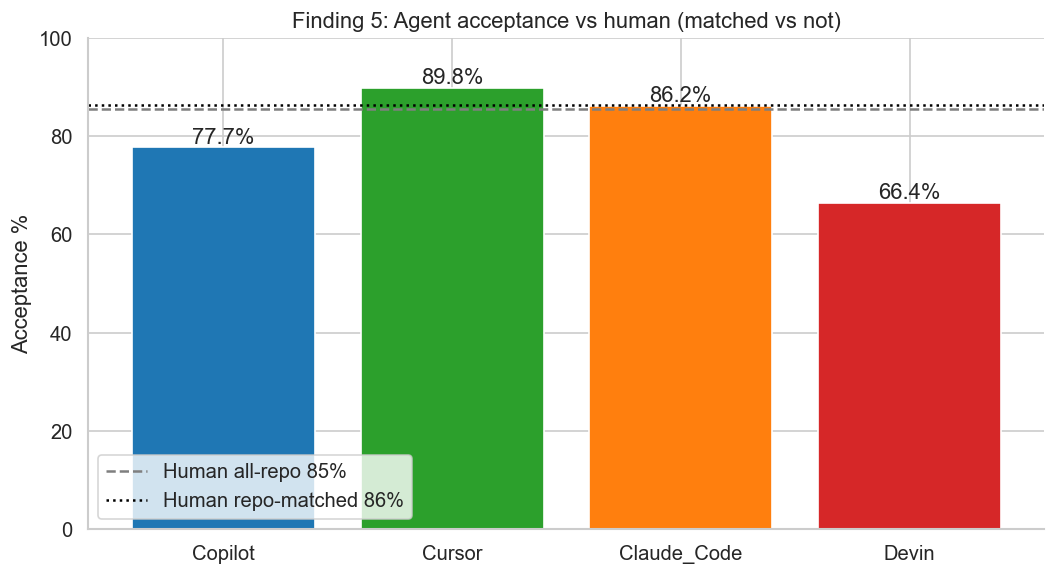

WindowsPath('results/paper_findings_figures/f5_repo_matched.png')

In [6]:
hu_m,hu_t,hu_r=merge_rate(human_df); hm_m,hm_t,hm_r=merge_rate(m_human_df)
print(f'Human acceptance — all repos: {hu_r:.1f}%  |  repo-matched: {hm_r:.1f}%')
print(f"{'Agent':<12}{'Rate%':>7}{'OR vs all':>22}{'OR vs matched':>22}")
rates=[]
for a in AGENTS:
    am,at,ar=merge_rate(agents_df[agents_df.agent==a]); rates.append(ar)
    ou,lu,hu=odds_ratio_ci(am,at,hu_m,hu_t); om,lm,hm=odds_ratio_ci(am,at,hm_m,hm_t)
    _,pu=chi_square(am,at,hu_m,hu_t); _,pm=chi_square(am,at,hm_m,hm_t)
    print(f'{a:<12}{ar:>6.1f}%   OR={ou:.2f}[{lu:.2f},{hu:.2f}]{sig_label(pu):>4}   OR={om:.2f}[{lm:.2f},{hm:.2f}]{sig_label(pm):>4}')
fig,ax=plt.subplots(figsize=(9,5))
ax.bar(AGENTS,rates,color=[AGENT_COLORS[a] for a in AGENTS])
ax.axhline(hu_r,color='#7f7f7f',ls='--',label=f'Human all-repo {hu_r:.0f}%')
ax.axhline(hm_r,color='black',ls=':',label=f'Human repo-matched {hm_r:.0f}%')
for i,v in enumerate(rates): ax.text(i,v,f'{v:.1f}%',ha='center',va='bottom')
ax.set_ylim(0,100); ax.set_ylabel('Acceptance %'); ax.legend(); ax.set_title('Finding 5: Agent acceptance vs human (matched vs not)')
fig.tight_layout(); save_fig(fig,'f5_repo_matched',FIG,show=True)

**Answer:** **not really.** Claude Code's edge over humans (OR 1.07) **disappears when matched on repo** (OR 0.99, n.s.). The apparent advantage is which repos agents work in, not better fixing. Copilot/Devin stay below humans; Cursor stays above.

**How:** odds ratio of each agent's merge rate vs. humans, computed on all human PRs and on a repo+time-matched human sample (same repo, ±30 days); p-values BH-adjusted.

**Takeaway:** unmatched per-agent comparisons (common in prior work) are confounded by repo choice.

## 6. Do agent fixes *hold up*? (reverts) — preliminary

Revert rate (merged fixes created <=2025-07-31): agents 0.22% vs humans 0.49%


  -> Saved: results\paper_findings_figures\f6_reverts.png


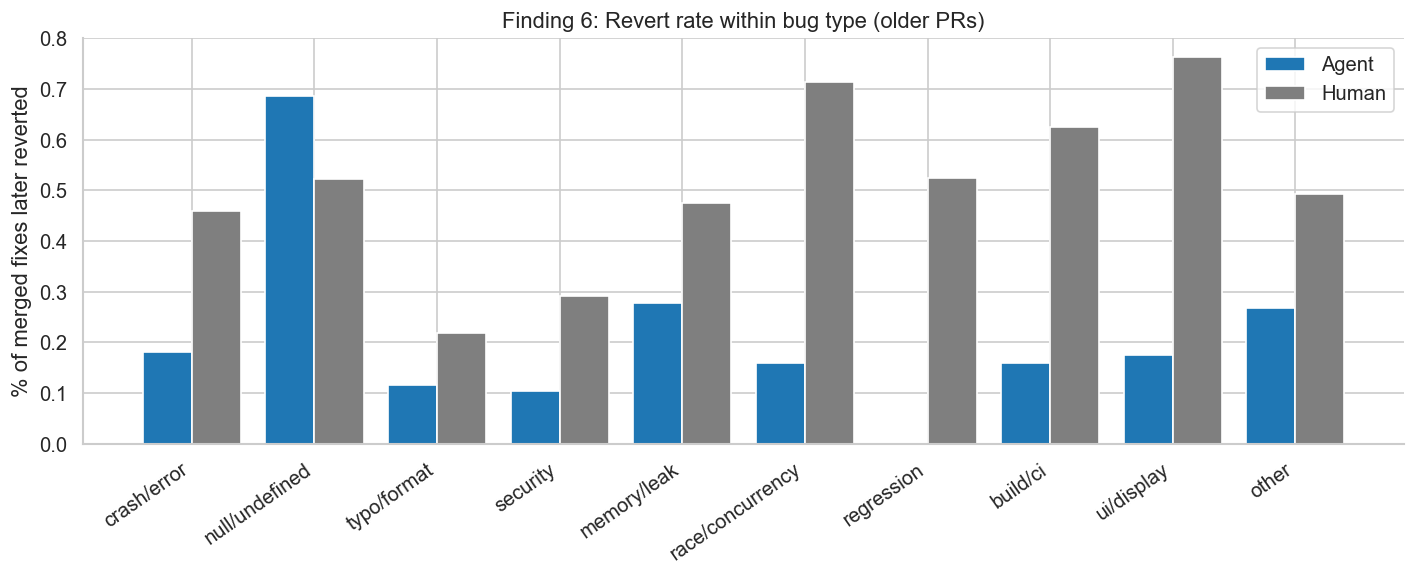

WindowsPath('results/paper_findings_figures/f6_reverts.png')

In [7]:
commits['message']=commits['message'].fillna('')
rev=commits[commits.message.str.contains('reverts commit',case=False,na=False)]
reverted=set(s[:12] for s in rev.message.str.extract(r'reverts commit ([0-9a-f]{7,40})',flags=re.I)[0].dropna())
commits['sha12']=commits['sha'].str[:12]
df['was_reverted']=df['id'].isin(set(commits.loc[commits.sha12.isin(reverted),'pr_id']))
old=df[df.created_at<=pd.Timestamp('2025-07-31',tz='UTC')]   # equal time-to-be-reverted
m_ag=old[old.is_merged & old.is_agent & old.agent.isin(AGENTS)]; m_hu=old[old.is_merged & ~old.is_agent]
print(f'Revert rate (merged fixes created <=2025-07-31): agents {m_ag.was_reverted.mean()*100:.2f}% vs humans {m_hu.was_reverted.mean()*100:.2f}%')
rows=[(c,m_ag[m_ag.bug_type==c].was_reverted.mean()*100,m_hu[m_hu.bug_type==c].was_reverted.mean()*100)
      for c in CATS if len(m_ag[m_ag.bug_type==c])>=150 and len(m_hu[m_hu.bug_type==c])>=150]
ct=pd.DataFrame(rows,columns=['bug_type','agent','human'])
fig,ax=plt.subplots(figsize=(12,5)); x=np.arange(len(ct)); w=0.4
ax.bar(x-w/2,ct['agent'],w,label='Agent',color='#1f77b4'); ax.bar(x+w/2,ct['human'],w,label='Human',color='#7f7f7f')
ax.set_xticks(x); ax.set_xticklabels(ct.bug_type,rotation=35,ha='right'); ax.legend()
ax.set_ylabel('% of merged fixes later reverted'); ax.set_title('Finding 6: Revert rate within bug type (older PRs)')
fig.tight_layout(); save_fig(fig,'f6_reverts',FIG,show=True)

**Answer (preliminary):** agent fixes are **reverted about half as often** (~0.22% vs ~0.49%), holding within most bug types even after equalizing exposure time — a tentative sign of more durable fixes.

**How:** find commits whose message says "This reverts commit <sha>", map that SHA to its PR, and take % of merged fixes later reverted — counting only PRs created by 2025-07-31 so each had equal time to be reverted.

**Caveat:** reverts are rare and only visible inside fix PRs, and **repo mix is not yet controlled** — so this is a promising lead, not a proven claim.

## 7. *How* do agents fix? (patch size by file role)

  -> Saved: results\paper_findings_figures\f7_patch_size_by_role.png


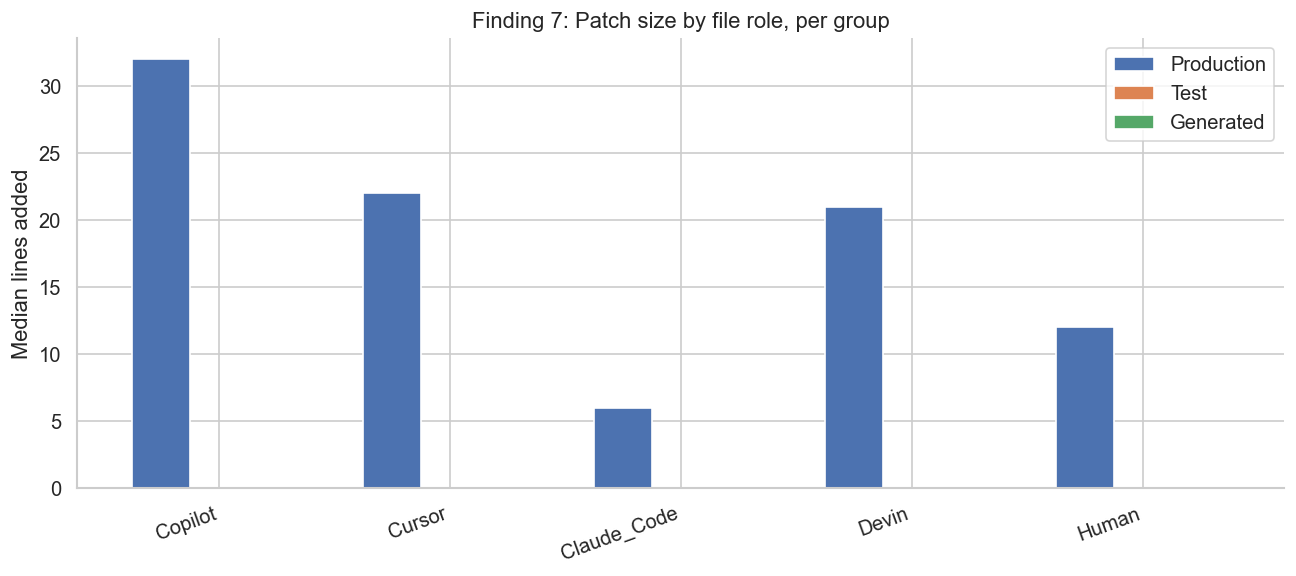

  Copilot      prod 32 | test 0 | generated 0
  Cursor       prod 22 | test 0 | generated 0
  Claude_Code  prod 6 | test 0 | generated 0
  Devin        prod 21 | test 0 | generated 0
  Human        prod 12 | test 0 | generated 0


In [8]:
roles=['prod_added','test_added','generated_added']; labels=['Production','Test','Generated']
groups=AGENTS+['Human']
med={r:[ (human_size if gp=='Human' else agents_size[agents_size.agent==gp])[r].median() for gp in groups] for r in roles}
xp=np.arange(len(groups)); w=0.25
fig,ax=plt.subplots(figsize=(11,5))
for i,(r,l) in enumerate(zip(roles,labels)): ax.bar(xp+(i-1)*w,med[r],w,label=l)
ax.set_xticks(xp); ax.set_xticklabels(groups,rotation=20,ha='right'); ax.legend()
ax.set_ylabel('Median lines added'); ax.set_title('Finding 7: Patch size by file role, per group')
fig.tight_layout(); save_fig(fig,'f7_patch_size_by_role',FIG,show=True)
for gp in groups:
    s=human_size if gp=='Human' else agents_size[agents_size.agent==gp]
    print(f'  {gp:<12} prod {s.prod_added.median():.0f} | test {s.test_added.median():.0f} | generated {s.generated_added.median():.0f}')

**Answer:** agents write **larger production patches than humans** — except **Claude Code, which is surgical** (smallest production diffs). Splitting by file role (prod/test/generated) is something prior bug-fix studies don't do.

**How:** classify each changed file as production/test/generated by its path, sum lines added per role per PR, then take the median per group.

**Caveat:** file role is inferred from path patterns (heuristic).

## Summary — 7 contributions (agentic bug-fix domain)

1. **Quality diverges over time** — Claude Code improves, Copilot/Cursor decline (Q1).
2. **Repos are agent-loyal** — 85% never switch; the market moves via newcomers (Q2).
3. **Instruction-file use is rising** and correlates with higher acceptance (Q3).
4. **Agents fix different bugs** — 3× more build/CI; security fixes trusted least.
5. **Agents don't truly out-merge humans** — Claude Code's edge is a repo-selection effect (matched OR≈1).
6. **Agent fixes may be more durable** — reverted ~half as often (preliminary).
7. **How they fix** — larger patches, but Claude Code is surgical; novel prod/test/generated split.

*Story: AI bug-fixing is not static — over 15 months agents specialize in a distinct slice of bugs, their quality shifts (and Copilot's falls as it scales), and their apparent advantages over humans largely reflect which repos they work in.*